# Feature Engineering Methods

## Set ML flow

In [1]:
import mlflow
import mlflow.sklearn
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import os


# Set the tracking URI to your custom folder
mlflow.set_tracking_uri(f"file:///home/anuarsantoyo/PycharmProjects/TS_Project_proposal/week_3/mlruns")
experiment_name = "favorita_sales_forecasting"
mlflow.set_experiment(experiment_name)

/home/anuarsantoyo/PycharmProjects/TS_Project_proposal/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/anuarsantoyo/PycharmProjects/TS_Project_proposal/.venv/lib/python3.12/site-packages/mlflow/tracking/_tracking_service/utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)
2026/02/09 04:02:29 INFO mlflow.tracking.fluent: Experiment with name 'favorita_sales_forecasting' does not exist. Crea

<Experiment: artifact_location='file:///home/anuarsantoyo/PycharmProjects/TS_Project_proposal/week_3/mlruns/492607176397065755', creation_time=1770606149347, experiment_id='492607176397065755', last_update_time=1770606149347, lifecycle_stage='active', name='favorita_sales_forecasting', tags={}>

# Create Features

In [17]:
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [18]:
df = pd.read_csv("../data/cleaned_timeseries.csv")
df['date'] = pd.to_datetime(df['date'])

In [20]:
# Lag features (per store and item)
df['lag_1'] = df['unit_sales'].shift(1)
df['lag_7'] = df['unit_sales'].shift(7)
df['lag_30'] = df['unit_sales'].shift(30)

# Rolling statistics
df['rolling_std_7'] = df['unit_sales'].shift(1).rolling(window=7).std()


In [21]:

df['day_of_week'] = df['date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)


In [22]:
df

,date,unit_sales,lag_1,lag_7,lag_30,rolling_std_7,day_of_week,is_weekend
0,2013-01-02,582.0,NaN,NaN,NaN,NaN,2,0
1,2013-01-03,310.0,582.0,NaN,NaN,NaN,3,0
2,2013-01-04,338.0,310.0,NaN,NaN,NaN,4,0
3,2013-01-05,654.0,338.0,NaN,NaN,NaN,5,1
4,2013-01-06,979.0,654.0,NaN,NaN,NaN,6,1
...,...,...,...,...,...,...,...,...
449,2014-03-27,328.0,432.0,139.0,453.0,152.001566,3,0
450,2014-03-28,523.0,328.0,456.0,388.0,101.609430,4,0
451,2014-03-29,647.0,523.0,567.0,587.0,105.370548,5,1
452,2014-03-30,599.0,647.0,603.0,346.0,122.007416,6,1


# ML Part

In [23]:
split_date = '2014-01-01'
train = df[df['date'] <= split_date]
test = df[df['date'] > split_date]

In [24]:
# Define target variable (unit_sales) and features
X_train = train.drop('unit_sales', axis=1)
X_train = X_train.drop('date', axis=1)
y_train = train['unit_sales']

X_test = test.drop('unit_sales', axis=1)
X_test = X_test.drop('date', axis=1)
y_test = test['unit_sales']

## XGBoost Model

In [30]:
# Initialize the XGBoost regressor
xgboost_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    enable_categorical=True
)

# Train the XGBoost model
xgboost_model.fit(X_train, y_train)
# Make predictions on the test set
y_pred = xgboost_model.predict(X_test)

In [ ]:
# Save to MLflow
with mlflow.start_run(run_name="Model"):
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    mlflow.log_param("model_type", "Model")
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("r2", r2)
    mlflow.sklearn.log_model(model, "linear_regression_model")


 MAE: 106.60230109396946, MSE: 23843.04969186271, R2: 0.2990499022283605


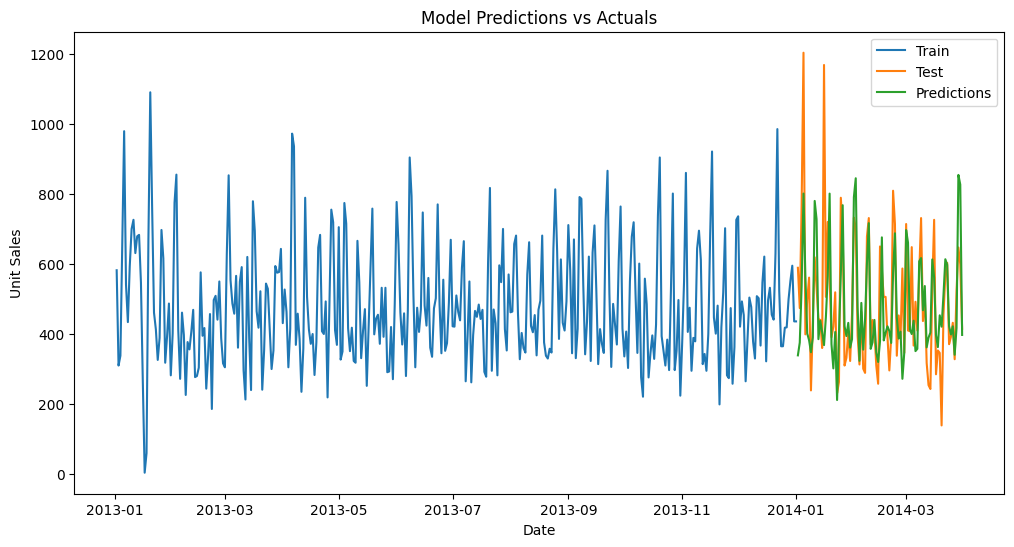

In [31]:
# visualize predictions against actuals and whole serie
plt.figure(figsize=(12, 6))
plt.plot(train['date'], train['unit_sales'], label='Train')
plt.plot(test['date'], test['unit_sales'], label='Test')
plt.plot(test['date'], y_pred, label='Predictions')
plt.title('Model Predictions vs Actuals')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.show()


## Sklearn Models

In [32]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR

# Initialize models
model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42) # You can switch to LinearRegression() or SVR() to test other models
# Train the model
model.fit(X_train, y_train)
# Make predictions
y_pred = model.predict(X_test)


In [33]:
# Save to MLflow
with mlflow.start_run(run_name="Model"):
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    mlflow.log_param("model_type", "Model")
    mlflow.log_metric("mse", mse)
    mlflow.log_metric("r2", r2)
    mlflow.sklearn.log_model(model, "linear_regression_model")

 MAE: 99.23454242591073, MSE: 20840.78374786464, R2: 0.3873120429435277


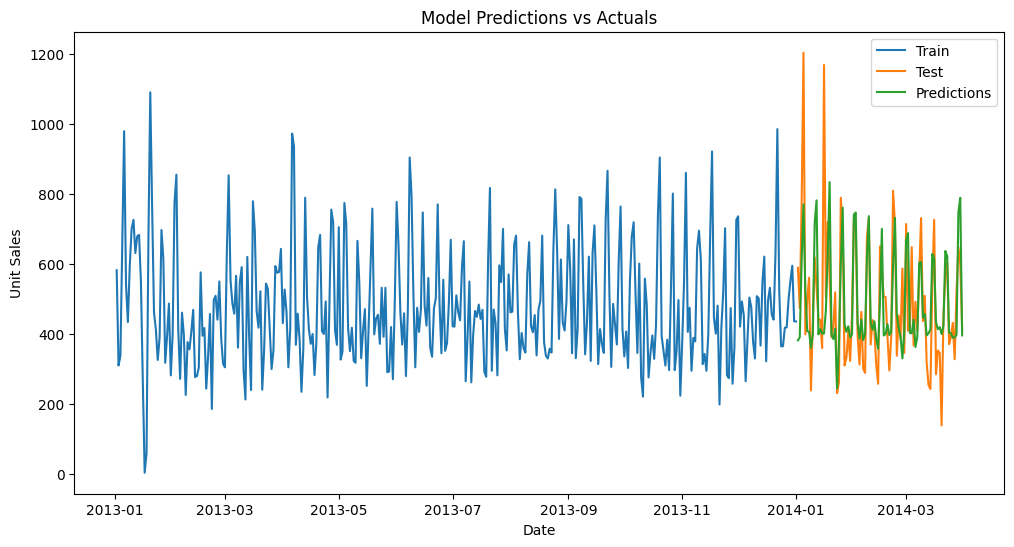

In [34]:
# visualize predictions against actuals and whole serie

plt.figure(figsize=(12, 6))
plt.plot(train['date'], train['unit_sales'], label='Train')
plt.plot(test['date'], test['unit_sales'], label='Test')
plt.plot(test['date'], y_pred, label='Predictions')
plt.title('Model Predictions vs Actuals')
plt.xlabel('Date')
plt.ylabel('Unit Sales')
plt.legend()
plt.show()
